# 3b — GBM Sweeps (v2.0)

Hyperparameter optimisation and feature analysis for the **Histogram Gradient Boosting Machine** (quantile regression).

| § | Stage | Description | Est. wall time |
|---|---|---|---|
| 2 | **Optuna HPO** | TPE 5-fold CV | 1–3 h |
| 3 | **Feature ablation** | LOO ΔR² with best params | ~30 min |
| 4 | **MC feature subset** | Random subset R² | 2–4 h |
| 5 | **Greedy forward** | Iterative best-feature build | 2–4 h |

Outputs → `output/sweeps/gbm_*.csv` | Figures → `fig/sweeps/gbm_*.png`

Best params written to `output/sweeps/gbm_params.json` (imported by `4_MODEL.ipynb`).

**Optuna search space:**  `max_iter` [100–800 step 50],  `max_depth` [3–10],  `learning_rate` [0.01–0.30 log],  `min_samples_leaf` [5–60],  `max_features` [0.3–1.0],  `l2_regularization` [0–5].  Warm-started from `config.py` defaults.

## 1. Imports & setup

In [1]:
import sys, json, time, warnings, platform, psutil, datetime
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from config import *

optuna.logging.set_verbosity(optuna.logging.WARNING)

sweep_dir.mkdir(parents=True, exist_ok=True)
(fig_root / 'sweeps').mkdir(parents=True, exist_ok=True)
fig_sweep = fig_root / 'sweeps'

print(f"sweep_dir : {sweep_dir}")
print(f"fig_sweep : {fig_sweep}")
from sklearn.ensemble import HistGradientBoostingRegressor


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
sweep_dir : output/sweeps
fig_sweep : fig/sweeps


## 0. Toggles

In [2]:
RUN_GBM_OPTUNA    = True
RUN_GBM_ABLATION  = True
RUN_GBM_MC        = True
RUN_GBM_GREEDY    = True

GBM_N_OPTUNA_TRIALS = N_OPTUNA_TRIALS
GBM_CALIBRATION_FRAC = 0.20
GBM_MC_N_RUNS       = MC_N_RUNS
GBM_MC_MIN_FEATS    = 5
GBM_MC_MAX_FEATS    = None
GBM_RANDOM_SEED     = 2026
GBM_MC_SEED         = 2025
GBM_GREEDY_SEED     = 2025
GBM_QUANTILES       = [0.05, 0.50, 0.95]


### 1a. Verify parquet

In [3]:
df_check = pd.read_parquet(parquet_ref, columns=obs_model + ['q'])
missing_m = [c for c in obs_model if c not in df_check.columns]
all_nan_m = [c for c in obs_model if df_check[c].isna().all()]
assert not missing_m, f'MISSING from parquet: {missing_m}'
assert not all_nan_m, f'ALL-NaN columns: {all_nan_m}'
print(f'\u2713 {len(obs_model)} obs_model features verified | q_clip_max={q_clip_max}')


✓ 21 obs_model features verified | q_clip_max=0.35


### 1b. Load reference data

In [4]:
obs_sel = obs_sweep  # NOTE: adjust here to test a different feature universe

df_ref    = pd.read_parquet(parquet_ref)
available = [f for f in obs_sel if f in df_ref.columns]
missing   = [f for f in obs_sel if f not in df_ref.columns]
if missing:
    warnings.warn(f'obs_sel columns missing from parquet: {missing}')
    raise RuntimeError(f'Missing features: {missing}')

cols_needed = available + ['q']
if 'weight' in df_ref.columns:
    cols_needed.append('weight')

work = (df_ref[cols_needed]
        .replace([np.inf, -np.inf], np.nan)
        .dropna())
work = work[(work['q'] >= q_clip_min) & (work['q'] <= q_clip_max)]

y_phys = work['q'].values
w_all  = work['weight'].values if 'weight' in work.columns else np.ones(len(work))
X_all  = work[available].values

print(f'Reference rows : {len(work):,}')
print(f'Features       : {len(available)}')
print(available)


Reference rows : 30,847
Features       : 22
['REVEAL_S70', 'REVEAL_S90', 'REVEAL_P150', 'DEM', 'FREE_AIR', 'MOHO', 'REVEAL_VP50VS80', 'BOUGUER', 'REVEAL_S100', 'CRUST_RHO', 'MOHO_GRAV', 'GEOID', 'MAG_SEIS_MOHO', 'CTD', 'LAB', 'REVEAL_S80', 'SI', 'LITH_RHO', 'EMAG2_LOG', 'REVEAL_VP60VS70', 'SEDIMENT', 'REVEAL_VP90VS60']


### 1c. Train / calibration split + StandardScaler

In [5]:
(X_train, X_cal,
 y_train_phys, y_cal_phys,
 w_train, _) = train_test_split(
    X_all, y_phys, w_all,
    test_size=GBM_CALIBRATION_FRAC, random_state=random_state,
)
sc_gbm  = StandardScaler()
X_tr_s  = sc_gbm.fit_transform(X_train)
X_cal_s = sc_gbm.transform(X_cal)
print(f'Train : {len(X_train):,}   Cal : {len(X_cal):,}')


Train : 24,677   Cal : 6,170


### 1d. Evaluation helper + baseline

In [6]:
def _gbm_eval(feat_idx, params):
    Xtr = X_tr_s[:, feat_idx];  Xca = X_cal_s[:, feat_idx]
    preds = {}
    t0 = time.time()
    for q in GBM_QUANTILES:
        mdl = HistGradientBoostingRegressor(
            loss='quantile', quantile=q,
            max_iter         =int(params.get('max_iter',         GB_MAX_ITER)),
            max_depth        =int(params.get('max_depth',        GB_MAX_DEPTH)),
            learning_rate    =float(params.get('learning_rate',  GB_LEARNING_RATE)),
            min_samples_leaf =int(params.get('min_samples_leaf', GB_MIN_SAMPLES_LEAF)),
            max_features     =float(params.get('max_features',   GB_MAX_FEATURES)),
            l2_regularization=float(params.get('l2_regularization', GB_L2_REG)),
            random_state=random_state)
        mdl.fit(Xtr, y_train_phys, sample_weight=w_train)
        preds[q] = np.clip(mdl.predict(Xca), q_clip_min, q_clip_max)
    p05, p50, p95 = preds[0.05], preds[0.50], preds[0.95]
    return dict(
        r2  =float(r2_score(y_cal_phys, p50)),
        rmse=float(np.sqrt(mean_squared_error(y_cal_phys, p50))),
        picp=float(np.mean((y_cal_phys >= p05) & (y_cal_phys <= p95))),
        elapsed_s=time.time()-t0)

DEFAULT_GBM = dict(max_iter=GB_MAX_ITER, max_depth=GB_MAX_DEPTH,
    learning_rate=GB_LEARNING_RATE, min_samples_leaf=GB_MIN_SAMPLES_LEAF,
    max_features=GB_MAX_FEATURES, l2_regularization=GB_L2_REG)

all_idx = list(range(len(available)))
print('Training GBM baseline (default params)...')
gbm_baseline = _gbm_eval(all_idx, DEFAULT_GBM)
gbm_base_r2  = gbm_baseline['r2']
print(f'  RMSE={gbm_baseline["rmse"]*1000:.2f} mW/m²  R²={gbm_base_r2:.4f}  '
      f'PICP={gbm_baseline["picp"]:.4f}  t={gbm_baseline["elapsed_s"]:.1f}s')


Training GBM baseline (default params)...
  RMSE=37.58 mW/m²  R²=0.2997  PICP=0.8947  t=14.0s


---
## 2. GBM Optuna HPO

TPE sampler. 5-fold CV on median quantile (q=0.50) as proxy objective.

In [7]:
gbm_optuna_csv  = sweep_dir / 'gbm_optuna_trials.csv'
t_gbm_opt_start = time.time()

if RUN_GBM_OPTUNA:
    def _objective_gbm(trial):
        p = dict(
            max_iter         =trial.suggest_int(  'max_iter',          100, 800, step=50),
            max_depth        =trial.suggest_int(  'max_depth',         3,   10),
            learning_rate    =trial.suggest_float('learning_rate',     0.01, 0.30, log=True),
            min_samples_leaf =trial.suggest_int(  'min_samples_leaf',  5,   60),
            max_features     =trial.suggest_float('max_features',      0.3,  1.0),
            l2_regularization=trial.suggest_float('l2_regularization', 0.0,  5.0),
        )
        kf  = KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=random_state)
        r2s = []
        for tr_i, te_i in kf.split(X_all):
            sc_cv = StandardScaler().fit(X_all[tr_i])
            mdl   = HistGradientBoostingRegressor(
                loss='quantile', quantile=0.50, random_state=random_state, **p)
            mdl.fit(sc_cv.transform(X_all[tr_i]), y_phys[tr_i], sample_weight=w_all[tr_i])
            pred  = np.clip(mdl.predict(sc_cv.transform(X_all[te_i])), q_clip_min, q_clip_max)
            r2s.append(r2_score(y_phys[te_i], pred))
        return float(np.mean(r2s))

    study_gbm = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=random_state))
    study_gbm.enqueue_trial(dict(max_iter=GB_MAX_ITER, max_depth=GB_MAX_DEPTH,
        learning_rate=GB_LEARNING_RATE, min_samples_leaf=GB_MIN_SAMPLES_LEAF,
        max_features=GB_MAX_FEATURES, l2_regularization=GB_L2_REG))
    study_gbm.optimize(_objective_gbm, n_trials=GBM_N_OPTUNA_TRIALS, show_progress_bar=True)
    best_gbm_params = study_gbm.best_params
    best_gbm_cv_r2  = study_gbm.best_value
    study_gbm.trials_dataframe().to_csv(gbm_optuna_csv, index=False)
    print(f'\nOptuna complete.  Best CV R² = {best_gbm_cv_r2:.4f}')
    for k, v in best_gbm_params.items(): print(f'  {k:22s} {v}')
elif gbm_optuna_csv.exists():
    df_opt = pd.read_csv(gbm_optuna_csv)
    best_row_opt = df_opt.loc[df_opt['value'].idxmax()]
    best_gbm_params = {c.replace('params_',''):best_row_opt[c]
                       for c in df_opt.columns if c.startswith('params_')}
    best_gbm_cv_r2  = float(best_row_opt['value'])
    print(f'Loaded {gbm_optuna_csv}  ({len(df_opt)} trials)  best CV R²={best_gbm_cv_r2:.4f}')
else:
    best_gbm_params = DEFAULT_GBM.copy();  best_gbm_cv_r2 = None
    print('No saved trials — set RUN_GBM_OPTUNA = True.')

t_gbm_opt_end = time.time()


  0%|          | 0/200 [00:00<?, ?it/s]


Optuna complete.  Best CV R² = 0.3210
  max_iter               800
  max_depth              10
  learning_rate          0.1423796562348902
  min_samples_leaf       35
  max_features           0.6647697138081574
  l2_regularization      0.14518047771116876


### 2a. Optuna scatter

✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36


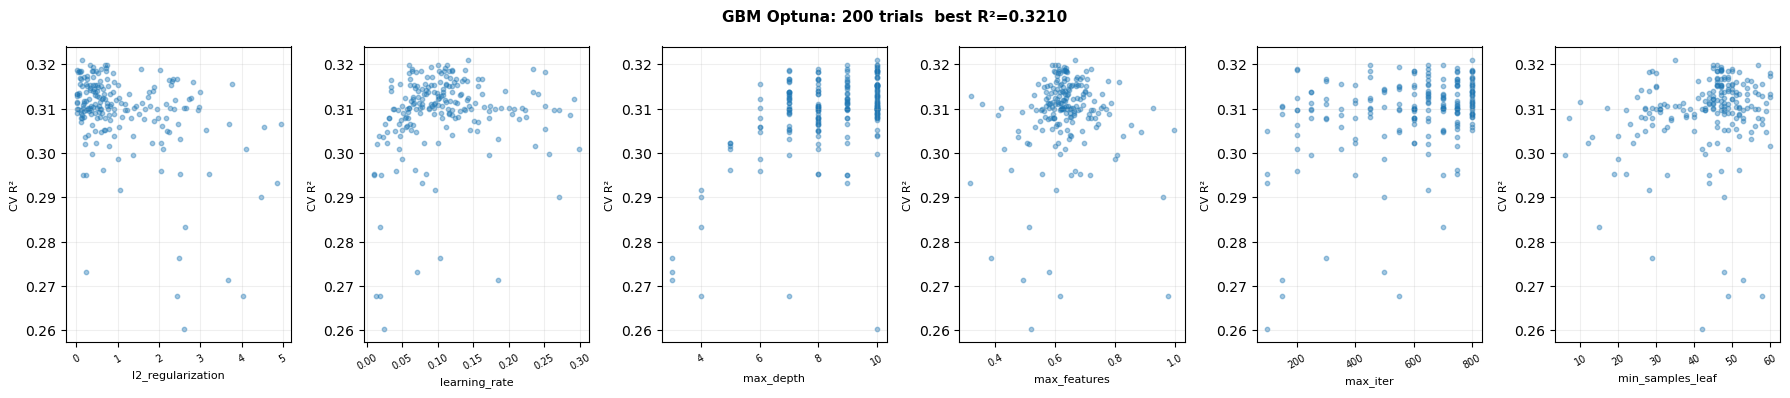

Saved fig/sweeps/gbm_optuna_scatter.png


In [8]:
if gbm_optuna_csv.exists():
    df_opt = pd.read_csv(gbm_optuna_csv)
    param_cols = [c for c in df_opt.columns if c.startswith('params_')]
    n_p = len(param_cols)
    fig, axes = plt.subplots(1, n_p, figsize=(3*n_p, 4))
    for ax, col in zip(axes, param_cols):
        ax.scatter(df_opt[col], df_opt['value'], alpha=0.4, s=10)
        ax.set_xlabel(col.replace('params_',''), fontsize=8)
        ax.set_ylabel('CV R²', fontsize=8)
        ax.tick_params(labelsize=7, axis='x', rotation=30);  ax.grid(True, alpha=0.2)
    fig.suptitle(f'GBM Optuna: {len(df_opt)} trials  best R²={best_gbm_cv_r2:.4f}',
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    fig.savefig(fig_sweep/'gbm_optuna_scatter.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/gbm_optuna_scatter.png')


---
## 3. Feature Ablation (LOO)

Uses best Optuna params.

In [9]:
gbm_ablation_csv = sweep_dir / 'gbm_ablation_results.csv'
t_gbm_abl_start  = time.time()

if RUN_GBM_ABLATION:
    gbm_abl_rows = []
    n = len(available)
    for i, feat in enumerate(available):
        idx_keep = [j for j in range(n) if j != i]
        res      = _gbm_eval(idx_keep, best_gbm_params)
        delta    = res['r2'] - gbm_base_r2
        tag      = 'HELPFUL' if delta < -0.002 else ('HARMFUL' if delta > 0.002 else 'neutral')
        gbm_abl_rows.append(dict(feature=feat, r2_without=res['r2'], delta_r2=delta, verdict=tag))
        print(f'{i+1:3d}/{n} drop {feat:28s}  R²={res["r2"]:.4f}  Δ={delta:+.4f}  {tag}')
    gbm_abl_df = pd.DataFrame(gbm_abl_rows).sort_values('delta_r2')
    gbm_abl_df.to_csv(gbm_ablation_csv, index=False)
    print(f'\nSaved {gbm_ablation_csv}')
elif gbm_ablation_csv.exists():
    gbm_abl_df = pd.read_csv(gbm_ablation_csv);  print(f'Loaded {gbm_ablation_csv}')
else:
    gbm_abl_df = None;  print('No saved results — set RUN_GBM_ABLATION = True.')

t_gbm_abl_end = time.time()


  1/22 drop REVEAL_S70                    R²=0.3063  Δ=+0.0066  HARMFUL
  2/22 drop REVEAL_S90                    R²=0.3094  Δ=+0.0097  HARMFUL
  3/22 drop REVEAL_P150                   R²=0.3026  Δ=+0.0030  HARMFUL
  4/22 drop DEM                           R²=0.2819  Δ=-0.0178  HELPFUL
  5/22 drop FREE_AIR                      R²=0.3066  Δ=+0.0069  HARMFUL
  6/22 drop MOHO                          R²=0.3026  Δ=+0.0029  HARMFUL
  7/22 drop REVEAL_VP50VS80               R²=0.3006  Δ=+0.0009  neutral
  8/22 drop BOUGUER                       R²=0.2994  Δ=-0.0003  neutral
  9/22 drop REVEAL_S100                   R²=0.2980  Δ=-0.0017  neutral
 10/22 drop CRUST_RHO                     R²=0.2917  Δ=-0.0080  HELPFUL
 11/22 drop MOHO_GRAV                     R²=0.2990  Δ=-0.0007  neutral
 12/22 drop GEOID                         R²=0.2992  Δ=-0.0005  neutral
 13/22 drop MAG_SEIS_MOHO                 R²=0.3184  Δ=+0.0187  HARMFUL
 14/22 drop CTD                           R²=0.3019  Δ=+0.0022  

### 3a. Ablation figure

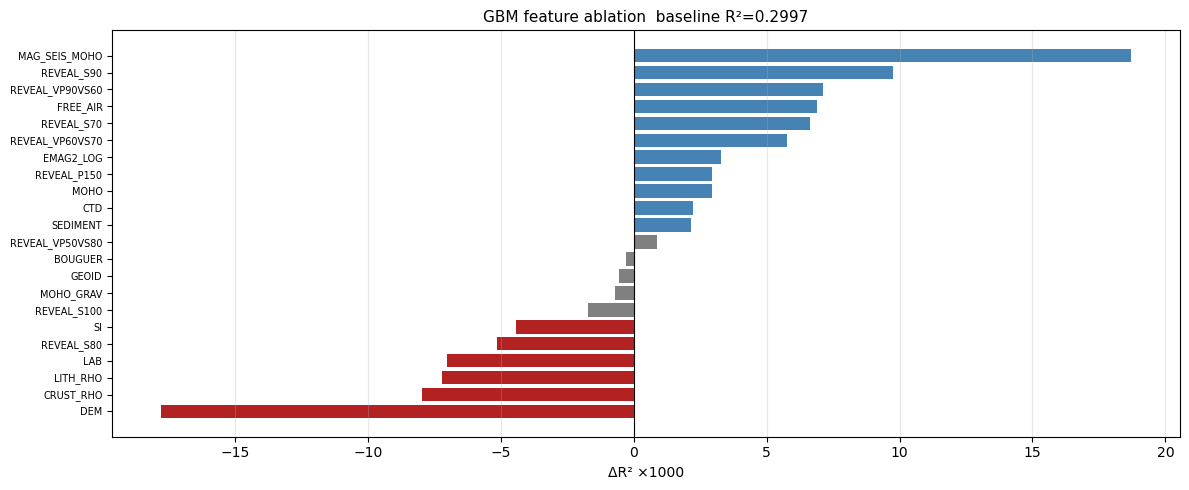

Saved fig/sweeps/gbm_ablation.png


In [10]:
if gbm_abl_df is not None and len(gbm_abl_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['firebrick' if v=='HELPFUL' else ('steelblue' if v=='HARMFUL' else 'grey')
              for v in gbm_abl_df['verdict']]
    ax.barh(gbm_abl_df['feature'], gbm_abl_df['delta_r2']*1000, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('ΔR² ×1000', fontsize=10)
    ax.set_title(f'GBM feature ablation  baseline R²={gbm_base_r2:.4f}', fontsize=11)
    ax.tick_params(axis='y', labelsize=7);  ax.grid(True, axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(fig_sweep/'gbm_ablation.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show();  print(f'Saved {fig_sweep}/gbm_ablation.png')


---
## 4. MC Feature-Subset Sweep

In [11]:
gbm_mc_csv      = sweep_dir / 'gbm_mc_results.csv'
t_gbm_mc_start  = time.time()
rng_mc_gbm      = np.random.default_rng(GBM_MC_SEED)
gbm_mc_max      = len(available)-1 if GBM_MC_MAX_FEATS is None else GBM_MC_MAX_FEATS
gbm_mc_rows     = pd.read_csv(gbm_mc_csv).to_dict('records') if gbm_mc_csv.exists() else []
mc_runs_needed  = GBM_MC_N_RUNS - len(gbm_mc_rows)

if RUN_GBM_MC and mc_runs_needed > 0:
    print(f'GBM MC runs to do: {mc_runs_needed}')
    for _ in range(mc_runs_needed):
        k       = int(rng_mc_gbm.integers(GBM_MC_MIN_FEATS, gbm_mc_max+1))
        idx_sel = sorted(rng_mc_gbm.choice(len(available), size=k, replace=False).tolist())
        res     = _gbm_eval(idx_sel, best_gbm_params)
        gbm_mc_rows.append(dict(n_feats=k,
            features='|'.join(available[i] for i in idx_sel),
            r2=res['r2'], rmse=res['rmse']))
        if len(gbm_mc_rows) % 10 == 0:
            pd.DataFrame(gbm_mc_rows).to_csv(gbm_mc_csv, index=False)
            print(f'  {len(gbm_mc_rows)}/{GBM_MC_N_RUNS}  R²={res["r2"]:.4f}  k={k}')
    gbm_mc_df = pd.DataFrame(gbm_mc_rows)
    gbm_mc_df.to_csv(gbm_mc_csv, index=False)
    print(f'Complete. Saved {gbm_mc_csv}')
elif gbm_mc_csv.exists():
    gbm_mc_df = pd.read_csv(gbm_mc_csv);  print(f'Loaded {gbm_mc_csv}')
else:
    gbm_mc_df = None;  print('No saved results — set RUN_GBM_MC = True.')

t_gbm_mc_end = time.time()


GBM MC runs to do: 300
  10/300  R²=0.2917  k=21
  20/300  R²=0.3070  k=18
  30/300  R²=0.2269  k=5
  40/300  R²=0.2847  k=8
  50/300  R²=0.2944  k=11
  60/300  R²=0.2966  k=12
  70/300  R²=0.2959  k=10
  80/300  R²=0.2945  k=17
  90/300  R²=0.2981  k=14
  100/300  R²=0.2990  k=21
  110/300  R²=0.2956  k=18
  120/300  R²=0.3023  k=12
  130/300  R²=0.3019  k=19
  140/300  R²=0.3010  k=13
  150/300  R²=0.3222  k=17
  160/300  R²=0.2885  k=7
  170/300  R²=0.3071  k=15
  180/300  R²=0.2978  k=17
  190/300  R²=0.3007  k=18
  200/300  R²=0.3019  k=14
  210/300  R²=0.3019  k=21
  220/300  R²=0.3048  k=19
  230/300  R²=0.2908  k=10
  240/300  R²=0.2861  k=16
  250/300  R²=0.3100  k=17
  260/300  R²=0.2602  k=6
  270/300  R²=0.2920  k=13
  280/300  R²=0.3040  k=18
  290/300  R²=0.2963  k=15
  300/300  R²=0.2982  k=15
Complete. Saved output/sweeps/gbm_mc_results.csv


---
## 5. Greedy Forward Selection

In [12]:
gbm_greedy_csv   = sweep_dir / 'gbm_greedy_forward.csv'
t_gbm_gr_start   = time.time()

if RUN_GBM_GREEDY:
    gbm_greedy_rows  = []
    remaining        = list(range(len(available)))
    selected_gbm     = []
    while remaining:
        best_r2_g, best_i_g, best_feat_g = -np.inf, None, None
        for i in remaining:
            res = _gbm_eval(selected_gbm + [i], best_gbm_params)
            if res['r2'] > best_r2_g:
                best_r2_g, best_i_g, best_feat_g = res['r2'], i, available[i]
        selected_gbm.append(best_i_g);  remaining.remove(best_i_g)
        gbm_greedy_rows.append(dict(step=len(selected_gbm), feature_added=best_feat_g,
            n_feats=len(selected_gbm), r2=best_r2_g,
            features_so_far='|'.join(available[i] for i in selected_gbm)))
        print(f'  step {len(selected_gbm):2d}  +{best_feat_g:28s}  R²={best_r2_g:.4f}')
    gbm_greedy_df = pd.DataFrame(gbm_greedy_rows)
    gbm_greedy_df.to_csv(gbm_greedy_csv, index=False)
    print(f'\nSaved {gbm_greedy_csv}')
elif gbm_greedy_csv.exists():
    gbm_greedy_df = pd.read_csv(gbm_greedy_csv);  print(f'Loaded {gbm_greedy_csv}')
else:
    gbm_greedy_df = None;  print('No saved results — set RUN_GBM_GREEDY = True.')

t_gbm_gr_end = time.time()


  step  1  +REVEAL_S70                    R²=0.1616
  step  2  +GEOID                         R²=0.2068
  step  3  +MOHO                          R²=0.2835
  step  4  +REVEAL_VP50VS80               R²=0.3010
  step  5  +REVEAL_VP90VS60               R²=0.3016
  step  6  +MOHO_GRAV                     R²=0.3126
  step  7  +FREE_AIR                      R²=0.3079
  step  8  +REVEAL_S80                    R²=0.3036
  step  9  +SEDIMENT                      R²=0.3191
  step 10  +LAB                           R²=0.3132
  step 11  +REVEAL_VP60VS70               R²=0.3176
  step 12  +REVEAL_S90                    R²=0.3162
  step 13  +REVEAL_S100                   R²=0.3143
  step 14  +BOUGUER                       R²=0.3161
  step 15  +CRUST_RHO                     R²=0.3150
  step 16  +SI                            R²=0.3154
  step 17  +LITH_RHO                      R²=0.3172
  step 18  +EMAG2_LOG                     R²=0.3232
  step 19  +CTD                           R²=0.3087
  step 20  +

---
## 6. Write `gbm_params.json`

In [13]:
gbm_json = param_paths['gbm']

best_gbm_out = dict(
    model='GBM', sweep_notebook='3b_GBM_SWEEP',
    best_cv_r2          = float(best_gbm_cv_r2) if best_gbm_cv_r2 is not None else None,
    max_iter            = int(best_gbm_params.get('max_iter',          GB_MAX_ITER)),
    max_depth           = int(best_gbm_params.get('max_depth',         GB_MAX_DEPTH)),
    learning_rate       = float(best_gbm_params.get('learning_rate',   GB_LEARNING_RATE)),
    min_samples_leaf    = int(best_gbm_params.get('min_samples_leaf',  GB_MIN_SAMPLES_LEAF)),
    max_features        = float(best_gbm_params.get('max_features',    GB_MAX_FEATURES)),
    l2_regularization   = float(best_gbm_params.get('l2_regularization', GB_L2_REG)),
    quantiles           = GBM_QUANTILES,
    obs_sel             = obs_sel,
    n_optuna_trials     = GBM_N_OPTUNA_TRIALS,
)
with open(gbm_json, 'w') as fp: json.dump(best_gbm_out, fp, indent=2)
print(f'Saved {gbm_json}')
for k, v in best_gbm_out.items():
    if k != 'obs_sel': print(f'  {k:22s} {v}')


Saved output/sweeps/gbm_params.json
  model                  GBM
  sweep_notebook         3b_GBM_SWEEP
  best_cv_r2             0.3210033170309486
  max_iter               800
  max_depth              10
  learning_rate          0.1423796562348902
  min_samples_leaf       35
  max_features           0.6647697138081574
  l2_regularization      0.14518047771116876
  quantiles              [0.05, 0.5, 0.95]
  n_optuna_trials        200


---
## 7. Runtime log

In [14]:
def _safe(x):
    try: return float(x)
    except: return None

log_df = pd.DataFrame([
    dict(stage='gbm_optuna',         wall_s=_safe(locals().get('t_gbm_opt_end',0) - locals().get('t_gbm_opt_start',0))),
    dict(stage='gbm_ablation_loo',   wall_s=_safe(locals().get('t_gbm_abl_end',0)  - locals().get('t_gbm_abl_start',0))),
    dict(stage='gbm_mc_subset',      wall_s=_safe(locals().get('t_gbm_mc_end',0)   - locals().get('t_gbm_mc_start',0))),
    dict(stage='gbm_greedy_forward', wall_s=_safe(locals().get('t_gbm_gr_end',0)   - locals().get('t_gbm_gr_start',0))),
])
log_df['wall_min'] = (log_df['wall_s'] / 60).round(2)
log_df.to_csv(sweep_dir/'gbm_runtime_log.csv', index=False)
print(log_df[['stage','wall_min']].to_string(index=False))
print(f'Saved {sweep_dir}/gbm_runtime_log.csv')


             stage  wall_min
        gbm_optuna    159.88
  gbm_ablation_loo      4.20
     gbm_mc_subset     50.70
gbm_greedy_forward     36.55
Saved output/sweeps/gbm_runtime_log.csv
